In [1]:
# data cleaning and visualization imports
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# scikitlearn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold

# modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# métricas
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import auc
from sklearn.metrics import average_precision_score

In [3]:
PROJECT_ROOT = Path(r"C:\kaggle_ev_purchase")
TRAIN_PATH = PROJECT_ROOT / "data" / "raw" / "train.csv"

TARGET = "Will_Buy_EV"
RANDOM_STATE = 42
ID_COL = "id"
HOLDOUT_SIZE = 0.15


def load_training_data(path):
    if not path.is_file():
        raise FileNotFoundError(f"Arquivo não encontrado: {path}")

    df = pd.read_csv(path)

    if df[TARGET].isna().any():
        raise ValueError("O alvo contém valores ausentes.")

    labels = set(df[TARGET].unique())

    if labels == {"Yes", "No"}:
        df[TARGET] = df[TARGET].map({"Yes": 1, "No": 0})
    elif labels != {0, 1}:
        raise ValueError(f"Valores inesperados no alvo: {labels}")

    df[TARGET] = df[TARGET].astype("int8")

    if df[ID_COL].isna().any() or not df[ID_COL].is_unique:
        raise ValueError("Existem IDs ausentes ou repetidos.")

    return df

In [4]:
train_df = load_training_data(TRAIN_PATH)
train_df.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,0
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,0
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,1
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,0
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,0


In [5]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  str    
 9   City_Type                    668665 non-null  str    
 10  Current_Car_Type             668665 non-null  str    
 11  Home_Charging_Possible       668665 non-null  str    
 12  Subsidy_Available            668665 non-null  str    
 13  Range_Anxi

valores unicos de colunas categóricas

In [6]:
cat_col = ['Gender', 'City_Type', 'Current_Car_Type',
         'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level']

num_col = ['Age', 'Annual_Income_USD', 'Daily_Commute_km',
       'Number_of_Cars_Owned', 'Charging_Stations_Near_Home',
       'Charging_Stations_Near_Work', 'Environmental_Concern_Level', 'Will_Buy_EV']


def show_cat_unique(df, colunas):
    for col in colunas:
        print(f'valores únicos da coluna: {col}')
        print(list(df[col].unique()))
        print(50*'=')

show_cat_unique(train_df, cat_col)

valores únicos da coluna: Gender
['Male', 'Female', 'Other']
valores únicos da coluna: City_Type
['Suburban', 'Rural', 'Urban']
valores únicos da coluna: Current_Car_Type
['Sedan', 'SUV', 'Hatchback', 'Truck']
valores únicos da coluna: Home_Charging_Possible
['Yes', 'No']
valores únicos da coluna: Subsidy_Available
['No', 'Yes']
valores únicos da coluna: Range_Anxiety_Level
['Low', 'Medium', 'High']


In [7]:
train_num = train_df[num_col]
train_num.describe()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Will_Buy_EV
count,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000
mean,47.039171,84769.266989,32.158298,1.712626,4.960408,7.176314,2.935477,0.174645
std,12.875448,28648.029042,18.730474,0.729275,3.926843,5.186627,1.429119,0.379663
min,25.000000,30000.000000,5.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,36.000000,67376.000000,17.200000,1.000000,2.000000,3.000000,2.000000,0.000000
50%,47.000000,84880.000000,33.600000,2.000000,4.000000,6.000000,3.000000,0.000000
75%,58.000000,102753.000000,47.400000,2.000000,7.000000,10.000000,4.000000,0.000000
max,69.000000,188549.000000,98.700000,4.000000,14.000000,19.000000,5.000000,1.000000


In [8]:
corr_matrix = train_num.corr()

corr_matrix['Will_Buy_EV'].sort_values(ascending=False)

Will_Buy_EV                    1.000000
Environmental_Concern_Level    0.464079
Annual_Income_USD              0.225729
Number_of_Cars_Owned           0.003896
Age                           -0.007450
Charging_Stations_Near_Work   -0.012229
Charging_Stations_Near_Home   -0.016353
Daily_Commute_km              -0.045866
Name: Will_Buy_EV, dtype: float64

In [9]:
total = len(train_df['Will_Buy_EV'])
targ_1 = len(train_df[train_df['Will_Buy_EV'] == 1])
targ_0 = len(train_df[train_df['Will_Buy_EV'] == 0])

print(f'proporção de positivos: {(targ_1/total)*100:.2f}%')
print(f'proporção de negativos: {(targ_0/total)*100:.2f}%')

proporção de positivos: 17.46%
proporção de negativos: 82.54%


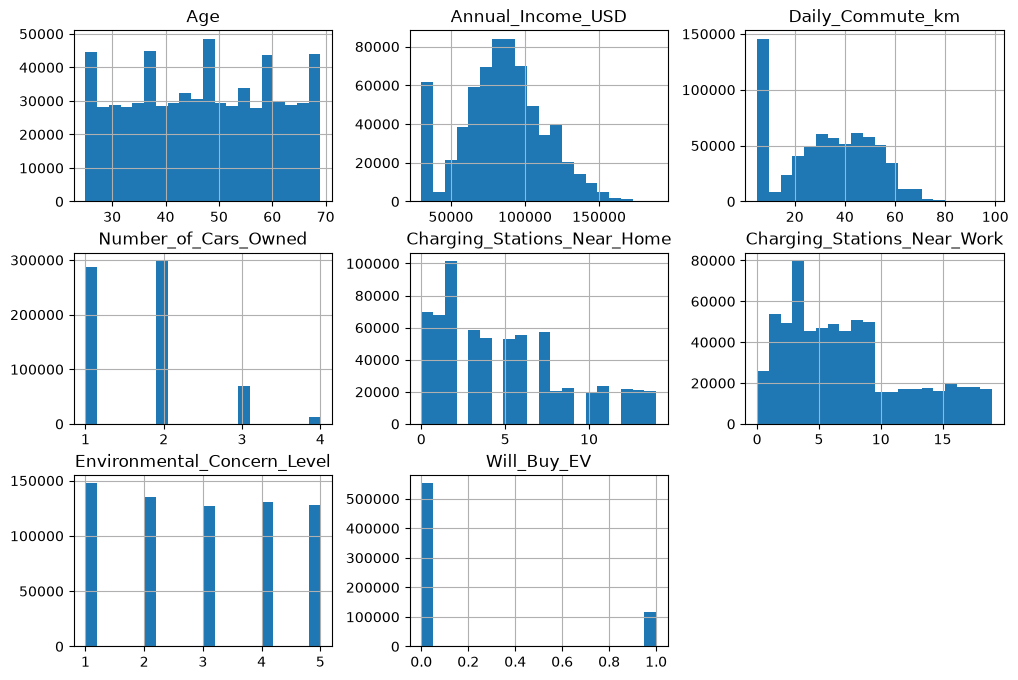

In [10]:
train_num.hist(bins=20, figsize=(12,8))
plt.show()

separando dados de desenvolvimento(treino) e holdout(validação) - além de TARGET

In [ ]:
X = train_df.drop(columns=[ID_COL, TARGET])
y = train_df[TARGET].copy()

X_dev, X_holdout, y_dev, y_holdout = train_test_split(
    X,
    y,
    test_size=HOLDOUT_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

# COLUNAS NUMÉRICAS
numeric_cols = X_dev.select_dtypes(include="number").columns.tolist()

# COLUNAS CATEGÓRICAS
categorical_cols = [
    col for col in X_dev.columns
    if col not in numeric_cols
]

Pipeline de processamento

In [12]:
cat_pipeline = Pipeline([('cat_encoder', OneHotEncoder(handle_unknown="ignore"))])
num_pipeline = Pipeline([('std_scaler', StandardScaler())])

preprocessor = ColumnTransformer([
                               ('num', num_pipeline, numeric_cols),
                               ('cat', cat_pipeline, categorical_cols)
])

Logistic Regression pipeline

In [13]:
log_reg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000,random_state=RANDOM_STATE)),
])

In [14]:
y_proba_log_reg = cross_val_predict(
    log_reg_pipeline,
    X_dev,
    y_dev,
    cv=3,
    method="predict_proba",
)[:, 1]

# Converte probabilidades em classes para precision e recall.
threshold = 0.5
y_pred_log_reg = (y_proba_log_reg >= threshold).astype(int)

print(f"ROC AUC - Logistic Regression: {roc_auc_score(y_dev, y_proba_log_reg):.5f}")
print(
    f"Precision - Logistic Regression: "
    f"{precision_score(y_dev, y_pred_log_reg, zero_division=0):.5f}"
)
print(
    f"Recall - Regression: "
    f"{recall_score(y_dev, y_pred_log_reg, zero_division=0):.5f}"
)

ROC AUC - Logistic Regression: 0.93806
Precision - Logistic Regression: 0.71792
Recall - Regression: 0.65657


In [15]:
conf_mx_log_reg = confusion_matrix(y_dev, y_pred_log_reg)
conf_mx_log_reg

array([[443496,  25607],
       [ 34090,  65172]])

In [16]:
# Curva ROC da regressão logística (validação cruzada)
fpr_log_reg, tpr_log_reg, thresholds_log_reg = roc_curve(y_dev, y_proba_log_reg)

def plot_roc_curve(curves):
       fig, ax = plt.subplots(figsize=(10, 6))

       for model_name, fpr, tpr in curves:
              roc_auc = auc(fpr, tpr)

              ax.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.5f})')

       
       ax.plot([0, 1], [0, 1], 'k--', label='Classificador aleatório (AUC = 0.5)')
       ax.set(xlim=(0, 1), ylim=(0, 1.02),
       xlabel='Taxa de falsos positivos',
       ylabel='Taxa de verdadeiros positivos (Recall)',
       title=f'Curvas ROC')
       ax.legend(loc='lower right')
       ax.grid(alpha=0.4)
       plt.tight_layout()
       plt.show()

Random Forest



In [17]:
rf_pipeline = Pipeline([
                        ('preprocessor', preprocessor),
                        ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100))
])

In [18]:
y_proba_rf = cross_val_predict(
                        rf_pipeline,
                        X_dev,
                        y_dev,
                        cv=3,
                        method='predict_proba'
)[:, 1]

y_pred_rf = (y_proba_rf >= threshold).astype(int)

print(f'ROC AUC - Random Forest: {roc_auc_score(y_dev, y_proba_rf):.5f}')
print(f'Precision Score - Random Forest: {precision_score(y_dev, y_pred_rf, zero_division=0):.5f}')
print(f'Recall Score - Random Forest: {recall_score(y_dev, y_pred_rf, zero_division=0):.5f}')


ROC AUC - Random Forest: 0.93190
Precision Score - Random Forest: 0.70614
Recall Score - Random Forest: 0.65361


In [19]:
conf_mx_rf = confusion_matrix(y_dev, y_pred_rf)
conf_mx_rf

array([[442104,  26999],
       [ 34383,  64879]])

In [20]:
fpr_rf, tpr_rf, threshold_rf = roc_curve(y_dev, y_proba_rf)

XGboost Classifier

In [21]:
xgb_pipeline = Pipeline([
                ('preprocessor', preprocessor),
                ('xgbclassifier', XGBClassifier())

])

In [22]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

param_distributions = {
    "xgbclassifier__n_estimators": [200, 400, 700],
    "xgbclassifier__max_depth": [2, 3, 4, 6],
    "xgbclassifier__learning_rate": [0.03, 0.05, 0.1],
    "xgbclassifier__min_child_weight": [1, 5, 15],
    "xgbclassifier__subsample": [0.8, 1.0],
    "xgbclassifier__colsample_bytree": [0.8, 1.0],
    "xgbclassifier__reg_lambda": [1, 5, 15],
}

search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_distributions,
    n_iter=15,
    scoring = "roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=2,
    verbose=1,
    refit=True,
    error_score='raise'
)

search.fit(X_dev, y_dev)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'xgbclassifier__colsample_bytree': [0.8, 1.0], 'xgbclassifier__learning_rate': [0.03, 0.05, ...], 'xgbclassifier__max_depth': [2, 3, ...], 'xgbclassifier__min_child_weight': [1, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"error_score error_score: 'raise' or numeric, default=np.nanValue to assign to the score if an error occurs in estimator fitting.If set to 'raise', the error is raised. If a numeric value is given,FitFailedWarning is raised. This parameter does not affect the refitstep, which will always raise the error.",'raise'
,"re

In [23]:
print("Melhor AUC média:", search.best_score_)
print("Melhores parâmetros:", search.best_params_)

best_pipeline = search.best_estimator_

Melhor AUC média: 0.9416804221081367
Melhores parâmetros: {'xgbclassifier__subsample': 0.8, 'xgbclassifier__reg_lambda': 5, 'xgbclassifier__n_estimators': 700, 'xgbclassifier__min_child_weight': 1, 'xgbclassifier__max_depth': 4, 'xgbclassifier__learning_rate': 0.05, 'xgbclassifier__colsample_bytree': 1.0}


In [24]:
auc_original = cross_val_score(
    xgb_pipeline,
    X_dev,
    y_dev,
    cv=cv,
    scoring="roc_auc",
)

print("Modelo original:", auc_original.mean())
print("Modelo otimizado:", search.best_score_)

Modelo original: 0.9406820061185984
Modelo otimizado: 0.9416804221081367


In [25]:
# Já está treinada em X_dev, pois a busca usou refit=True.
y_proba_holdout = best_pipeline.predict_proba(X_holdout)[:, 1]
y_pred_holdout = (y_proba_holdout >= 0.5).astype(int)

print("AUC:", roc_auc_score(y_holdout, y_proba_holdout))
print(
    "Precision:",
    precision_score(y_holdout, y_pred_holdout, zero_division=0),
)
print(
    "Recall:",
    recall_score(y_holdout, y_pred_holdout, zero_division=0),
)

AUC: 0.9419411541378779
Precision: 0.723979121891311
Recall: 0.6730604555574584


---------------------------------------------------------------

In [26]:
y_proba_xgb = cross_val_predict(
                        xgb_pipeline,
                        X_dev,
                        y_dev,
                        cv=3,
                        method='predict_proba'
)[:, 1]

In [27]:
y_pred_xgb = (y_proba_xgb >= threshold).astype(int)

print(f'ROC AUC - XGBClassifier: {roc_auc_score(y_dev, y_proba_xgb):.5f}')
print(f'Precision Score - XGBClassifier: {precision_score(y_dev, y_pred_xgb, zero_division=0):.5f}')
print(f'Recall Score - XGBClassifier: {recall_score(y_dev, y_pred_xgb, zero_division=0):.5f}')

ROC AUC - XGBClassifier: 0.94090
Precision Score - XGBClassifier: 0.72367
Recall Score - XGBClassifier: 0.67198


In [28]:
conf_mx_xgb = confusion_matrix(y_dev, y_pred_xgb)
conf_mx_xgb

array([[443633,  25470],
       [ 32560,  66702]])

In [30]:
fpr_xgb, tpr_xgb, threshold_xgb = roc_curve(y_holdout, y_proba_holdout)

comparação de curvas ROC entre modelos

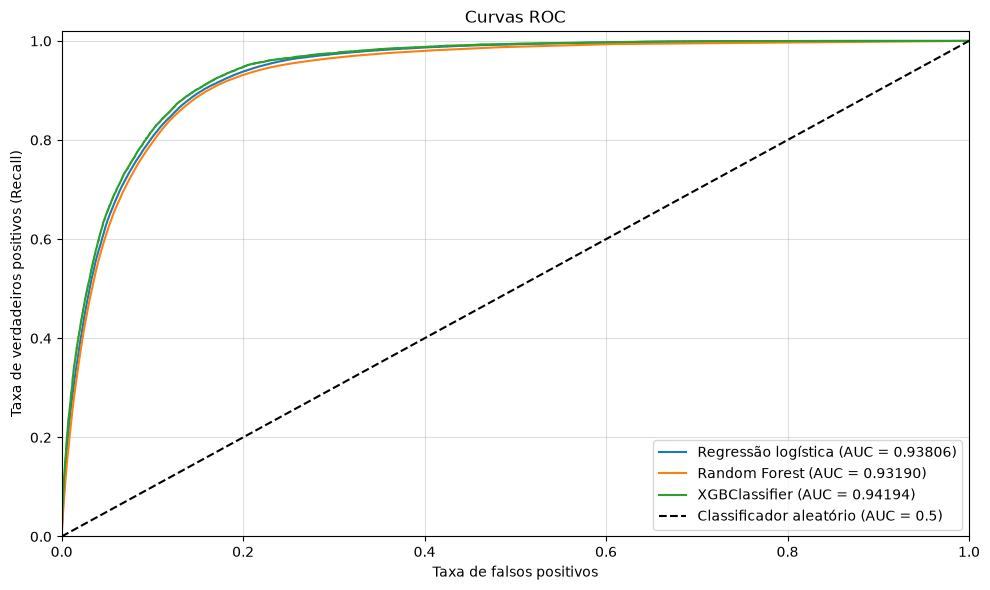

In [31]:
curves = [
    ('Regressão logística', fpr_log_reg, tpr_log_reg),
    ('Random Forest', fpr_rf, tpr_rf),
    ('XGBClassifier', fpr_xgb, tpr_xgb)
    
]

plot_roc_curve(curves)

--------------------------------------------------------------

dados de teste

In [32]:
test_df = pd.read_csv(PROJECT_ROOT / "data/raw/test.csv")

submission = pd.read_csv(
    PROJECT_ROOT / "data/raw/sample_submission.csv"
)

In [33]:
from sklearn.base import clone

X = train_df.drop(columns=[ID_COL, TARGET])
y = train_df[TARGET]

X_test = test_df.drop(columns=[ID_COL])

# Confere as colunas e mantém a mesma ordem do treinamento.
assert set(X_test.columns) == set(X.columns)
X_test = X_test[X.columns]

# Copia a configuração vencedora e treina em todos os dados.
final_pipeline = clone(search.best_estimator_)
final_pipeline.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('xgbclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['Age','Annual_Income_USD','Daily_Commute_km',...,'Home_Charging_Possible', 'Subsidy_Available','Range_Anxiety_Level']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'d

In [34]:
positive_index = list(final_pipeline.classes_).index(1)

test_probabilities = final_pipeline.predict_proba(X_test)[
    :, positive_index
]

In [35]:
assert test_df[ID_COL].is_unique
assert submission[ID_COL].equals(test_df[ID_COL])

submission[TARGET] = test_probabilities

assert submission[TARGET].notna().all()
assert submission[TARGET].between(0, 1).all()

display(submission.head())
print("Quantidade de previsões:", len(submission))

,id,Will_Buy_EV
0,668665,0.009616
1,668666,0.018646
2,668667,0.005263
3,668668,0.003183
4,668669,0.020895


Quantidade de previsões: 286571


In [36]:
submission_dir = PROJECT_ROOT / "submissions"
submission_dir.mkdir(parents=True, exist_ok=True)

submission_path = submission_dir / "submission_xgb_v1.csv"

submission.to_csv(submission_path, index=False)

print("Arquivo salvo em:", submission_path)

Arquivo salvo em: C:\kaggle_ev_purchase\submissions\submission_xgb_v1.csv


In [37]:
submission

,id,Will_Buy_EV
0,668665,0.009616
1,668666,0.018646
2,668667,0.005263
3,668668,0.003183
4,668669,0.020895
...,...,...
286566,955231,0.000204
286567,955232,0.257983
286568,955233,0.001905
286569,955234,0.000324
